# Google Play Store Apps Dataset Analysis

## Dataset Overview

The Google Play Store dataset is a comprehensive collection of metadata for over 10,000 Android applications available on the Google Play Store, covering the period from 2010 to 2018. This dataset offers a rich repository of insights into the Android app ecosystem, including user engagement metrics, pricing strategies, category distributions, and performance indicators. By analyzing this data, we can uncover trends in app popularity, user preferences, and market dynamics, providing valuable guidance for developers, marketers, and researchers interested in mobile app trends.

## Dataset Features

The following table outlines the key features of the dataset, each with a concise description:

| Feature          | Description                                                                 |
|------------------|-----------------------------------------------------------------------------|
| App              | The unique name of the Android application.                                 |
| Category         | The primary category under which the app is classified (e.g., Games, Tools). |
| Rating           | The average user rating of the app, on a scale of 1 to 5.                   |
| Reviews          | The total number of user reviews submitted for the app.                     |
| Size             | The storage size required by the app (e.g., in MB, or "Varies with device").|
| Installs         | The approximate number of downloads and installations (e.g., 1,000+).       |
| Type             | The pricing model of the app: "Free" or "Paid".                             |
| Price            | The monetary cost of the app, if applicable (e.g., $0.99).                  |
| Content Rating   | The age-appropriate rating for the app's content (e.g., "Everyone", "Teen").|
| Genres           | A detailed sub-classification within the primary category.                  |
| Last Updated     | The date when the app was last updated on the Play Store.                   |
| Current Ver      | The current version number of the app (e.g., 1.0.0).                        |
| Android Ver      | The minimum required Android OS version (e.g., 4.0.3 and up).               |

## Project Phases

### Phase 1: Data Cleaning and Preparation
In the initial phase of this project, we focus on cleaning and preparing the raw dataset to ensure its quality and usability. This involves handling missing values, correcting inconsistencies (such as non-numeric entries in numeric fields), standardizing formats (e.g., converting install counts to integers), and removing duplicates or irrelevant records. By the end of this phase, the dataset will be transformed into a reliable foundation for subsequent analysis.

### Phase 2: Exploratory Data Analysis (EDA)
Building on the cleaned data, the next phase involves conducting Exploratory Data Analysis (EDA) through a series of targeted questions. These questions will guide our investigation into key patterns and relationships, such as:
- What are the most popular app categories by installs and ratings?
- How does pricing influence download volumes across different genres?
- What trends emerge in user ratings over time?

This structured approach will illuminate actionable insights, visualized through charts and statistical summaries, to deepen our understanding of the Google Play Store landscape.

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import re
import warnings
warnings.filterwarnings("ignore")



In [164]:
data = pd.read_csv('/kaggle/input/google-play-store-apps-dataset/google_play_store_dataset.csv')

In [165]:
data.sample(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
893,Talking Ben the Dog,ENTERTAINMENT,4.3,1633682,57M,"100,000,000+",Free,0,Everyone,Entertainment,"July 3, 2018",3.5.2.2,4.1 and up
8841,Deep Sleep Battery Saver Pro,TOOLS,3.9,1417,2.9M,"10,000+",Paid,$3.28,Everyone,Tools,"August 15, 2017",5.1,4.1 and up


In [166]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [167]:
data.isna().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [168]:
data.columns=data.columns.str.replace(' ','_')

In [169]:
print('before:',len(data[data.duplicated]))
data.drop_duplicates(inplace=True)
print('After:',len(data[data.duplicated]))

before: 483
After: 0


Start of Phase 1 — Data Preparation

--- Category Column --- Start

In [170]:
print(data.Category.unique(),'\n')
print(data.Category.mode())
data.Category = data.Category.str.replace('1.9','FAMILY')

['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION' '1.9'] 

0    FAMILY
Name: Category, dtype: object


--- Category Column --- End

--- Rating Column --- Start  

In [171]:
print(data.Rating.unique())
data.Rating=data.Rating.replace(19.,1.9)

[ 4.1  3.9  4.7  4.5  4.3  4.4  3.8  4.2  4.6  3.2  4.   nan  4.8  4.9
  3.6  3.7  3.3  3.4  3.5  3.1  5.   2.6  3.   1.9  2.5  2.8  2.7  1.
  2.9  2.3  2.2  1.7  2.   1.8  2.4  1.6  2.1  1.4  1.5  1.2 19. ]


--- Rating Column --- End

--- Reviews Column --- start

In [172]:
pattern=r'[a-zA-z]'
print(data.Reviews[data.Reviews.str.contains(pattern)])
data.Reviews=data.Reviews.replace('3.0M',3000000)
data.Reviews=data.Reviews.astype(int)

10472    3.0M
Name: Reviews, dtype: object


--- Reviews Column --- End

--- Size Column --- Start

In [173]:
print(data.sample(5)['Size'].reset_index())
pattern=r'[Mk]'
print(data.Size[~data.Size.str.contains(pattern)].unique())

   index                Size
0   6946                8.2M
1   9597  Varies with device
2   6414                 10M
3  10061                 21M
4   7321                 14M
['Varies with device' '1,000+']


In [174]:
s = data['Size'].str.replace('Varies with device', '0').str.replace('1,000+','1.0')

extracted = s.str.extract(r'^([\d\.]+)([Mk])$')

extracted[0] = pd.to_numeric(extracted[0], errors='coerce')
data['Size_num'] = np.where(
    extracted[1].str.lower() == 'k',
    extracted[0] / 1000,
    extracted[0]
)
data.drop(columns='Size',inplace=True)

--- Size Columns --- End


--- Installs Column --- Start

In [175]:
print(data.Installs.unique())
print('Free',len(data[data.Installs == 'Free']),'\n','*'*70)
print('0 : ',len(data[data.Installs == '0']))
print('0+ : ',len(data[data.Installs == '0+']))
data.Installs = data.Installs.str.replace('[,+]','',regex=True).str.replace('Free','0').astype(np.float64)
data.Installs = data.Installs.replace(0,np.nan)
print('\nCleaned:',data.Installs.apply(lambda x: f'{x:.1f}').unique())

['10,000+' '500,000+' '5,000,000+' '50,000,000+' '100,000+' '50,000+'
 '1,000,000+' '10,000,000+' '5,000+' '100,000,000+' '1,000,000,000+'
 '1,000+' '500,000,000+' '50+' '100+' '500+' '10+' '1+' '5+' '0+' '0'
 'Free']
Free 1 
 **********************************************************************
0 :  1
0+ :  14

Cleaned: ['10000.0' '500000.0' '5000000.0' '50000000.0' '100000.0' '50000.0'
 '1000000.0' '10000000.0' '5000.0' '100000000.0' '1000000000.0' '1000.0'
 '500000000.0' '50.0' '100.0' '500.0' '10.0' '1.0' '5.0' 'nan']


--- Installs Columns --- End

---type Column --- start

In [176]:
#Type Column
print(data.Type.unique())
data.Type = data.Type.map({'Free':0,'Paid':1})
print('\nCleaned',data.Type.unique())

['Free' 'Paid' nan '0']

Cleaned [ 0.  1. nan]


---type Column --- End

--- Price Column --- Start

In [177]:
#Price Column
print(data.Price.unique(),'\n','*'*70)
pattern = r'[$]'
print(data.Price[~data.Price.str.contains(pattern)].unique(),'\n---')
print('Everyone:',len(data[data.Price =='Everyone']))
print('0:',len(data[data.Price =='0']))
data.Price = data.Price.str.replace('[$Everyone]','0', regex=True).astype(np.float64)
print('*'*70)
print(data.Price.unique())

['0' '$4.99' '$3.99' '$6.99' '$1.49' '$2.99' '$7.99' '$5.99' '$3.49'
 '$1.99' '$9.99' '$7.49' '$0.99' '$9.00' '$5.49' '$10.00' '$24.99'
 '$11.99' '$79.99' '$16.99' '$14.99' '$1.00' '$29.99' '$12.99' '$2.49'
 '$10.99' '$1.50' '$19.99' '$15.99' '$33.99' '$74.99' '$39.99' '$3.95'
 '$4.49' '$1.70' '$8.99' '$2.00' '$3.88' '$25.99' '$399.99' '$17.99'
 '$400.00' '$3.02' '$1.76' '$4.84' '$4.77' '$1.61' '$2.50' '$1.59' '$6.49'
 '$1.29' '$5.00' '$13.99' '$299.99' '$379.99' '$37.99' '$18.99' '$389.99'
 '$19.90' '$8.49' '$1.75' '$14.00' '$4.85' '$46.99' '$109.99' '$154.99'
 '$3.08' '$2.59' '$4.80' '$1.96' '$19.40' '$3.90' '$4.59' '$15.46' '$3.04'
 '$4.29' '$2.60' '$3.28' '$4.60' '$28.99' '$2.95' '$2.90' '$1.97'
 '$200.00' '$89.99' '$2.56' '$30.99' '$3.61' '$394.99' '$1.26' 'Everyone'
 '$1.20' '$1.04'] 
 **********************************************************************
['0' 'Everyone'] 
---
Everyone: 1
0: 9592
**********************************************************************
[  0.     4.9

--- Price Column --- End

--- Content_Rating Column --- Start

In [178]:
#Content_Rating	column
print(data.Content_Rating.unique(),'\n','*'*50)
print(data.Content_Rating.value_counts())
mapping  = {'Everyone':0, 'Everyone 10+':1,'Teen':2,'Mature 17+':3,'Adults only 18+':4,'Unrated':-1}
data.Content_Rating = data.Content_Rating.map(mapping).astype(np.float64).replace({-1:np.nan})
print('\n',data.Content_Rating.value_counts())

['Everyone' 'Teen' 'Everyone 10+' 'Mature 17+' 'Adults only 18+' 'Unrated'
 nan] 
 **************************************************
Content_Rating
Everyone           8382
Teen               1146
Mature 17+          447
Everyone 10+        377
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

 Content_Rating
0.0    8382
2.0    1146
3.0     447
1.0     377
4.0       3
Name: count, dtype: int64


--- Content_Rating Column --- End

--- Genres Column --- Start

In [179]:
pattern = r'[1234567890]'
print(data.Genres[data.Genres.str.contains(pattern)],'\n')
print(data.Genres.mode())
data.Genres = data.Genres.str.replace('February 11, 2018','Tools')

10472    February 11, 2018
Name: Genres, dtype: object 

0    Tools
Name: Genres, dtype: object


--- Genres Column --- End

--- Last_Updated Column --- Srart

In [180]:
#Last_Updated Column
print(data.Last_Updated[0:5],'\n')
pattern = r'^(?:January|February|March|April|May|June|July|August|September|October|November|December) \d{1,2}, \d{4}$'
print(data.Last_Updated[~data.Last_Updated.str.contains(pattern)])
print('---'*20)
print(data.Last_Updated.mode(),'\n')
data.Last_Updated = data.Last_Updated.str.replace('1.0.19','August 3, 2018')
data.Last_Updated = pd.to_datetime(data.Last_Updated, errors='coerce')
print(data.Last_Updated.dtype,'---->',data.Last_Updated.isna().sum())

0     January 7, 2018
1    January 15, 2018
2      August 1, 2018
3        June 8, 2018
4       June 20, 2018
Name: Last_Updated, dtype: object 

10472    1.0.19
Name: Last_Updated, dtype: object
------------------------------------------------------------
0    August 3, 2018
Name: Last_Updated, dtype: object 

datetime64[ns] ----> 0


--- Last_Updated Column --- End

--- Current_Ver Column --- Start

In [181]:
#Current_Ver
pattern1 = r'[a-zA-Z]'
print(data.Current_Ver[data.Current_Ver.str.contains(pattern1,na=False)].unique())
print('****'*20)
pattern2 = r'(\d\.\d)'
extracted = data.Current_Ver.str.extract(pattern2)
extracted[0] =pd.to_numeric(extracted[0], errors='coerce')
extracted[0] = extracted[0].replace(0, np.nan)
data.Current_Ver = extracted[0]
print(data.Current_Ver.unique())


['Varies with device' '2.20 Build 02' '3.0.1.11 (Build 311)' '3.4.3_world'
 'R6.0.3' '1.60.0.31354-release' '37.1.206017801.DR37_RC14' '4.4B'
 '1.308.us' '3.8.75a' '4.9.2 (Oasis)' '1.5-beta' '3.6.0.115_FN' '1.5-play'
 '1.1.1-play' 'v1.8b22p13' '2.3.34 Prod' 'Cannonau 3.11.11' '8.0bld14'
 '4.1.1-0-prod' '3.04 - Beta' '3.2.0d' '2.76.2.0-android' 'p5.7.1'
 '7.3.4-play' 'Public.Heal' '1.31.0-15160.950adac99' 'v3.1.1'
 '2.4.12-r244' 'Version:6.97' '3.8.5.Go' '1.2.3-play' '3.2.0h'
 '1.10.0.user.pro.release' '4.1.5 (Steglitz)' '1.830.0.564-(e405bb2)'
 '1.2.3-DEBUG' '1.0 Super Ear Hearing' 'PN.1.0' 'Initial' '2.5.0 b665'
 '1.4.15-free' 'T4.6.5-tl2.0.1' '50.2 lite' '2.9.9go' '10.9.8 (Play)'
 '11.0.269 (m)' 'v5.4.3' 'v3.7.93' 'MyMetro_HTML_2.0_430029'
 'v8.0.1.8.0629.1' '4.5.28_ww' 'v7.0.7.1.0625.1_06_0629'
 'v7.0.9.1.0526.1_06_0704' '1.8.203182757.armeabi-v7a.release' 'v150'
 'v3.9f' '3.6.21_pre' '3.3.a' '1.9.1.180419172630.4a15962'
 '1.9.2.180419172639.dbf3246' '2.2.1B216' '3.2.258b ae1da5165'

--- Current_Ver Column --- End

--- Android_Ver Column --- Start

In [182]:
#Android_Ver
pattern1 = r'[a-zA-Z]'
print(data.Android_Ver[data.Android_Ver.str.contains(pattern1,na=False)].unique())
print('****'*20)
pattern2 = r'(\d.\d)'
extracted = data.Android_Ver.str.extract(pattern2)
extracted[0] =pd.to_numeric(extracted[0], errors='coerce')
data.Android_Ver = extracted[0]
print(data.Android_Ver.unique())

['4.0.3 and up' '4.2 and up' '4.4 and up' '2.3 and up' '3.0 and up'
 '4.1 and up' '4.0 and up' '2.3.3 and up' 'Varies with device'
 '2.2 and up' '5.0 and up' '6.0 and up' '1.6 and up' '1.5 and up'
 '2.1 and up' '7.0 and up' '5.1 and up' '4.3 and up' '2.0 and up'
 '3.2 and up' '4.4W and up' '7.1 and up' '8.0 and up' '3.1 and up'
 '2.0.1 and up' '1.0 and up']
********************************************************************************
[4.  4.2 4.4 2.3 3.  4.1 nan 2.2 5.  6.  1.6 1.5 2.1 7.  5.1 4.3 2.  3.2
 7.1 8.  3.1 1. ]


--- Android_Ver Column --- End

In [183]:
data.isna().sum()

App                  0
Category             0
Rating            1465
Reviews              0
Installs            16
Type                 2
Price                0
Content_Rating       3
Genres               0
Last_Updated         0
Current_Ver       1601
Android_Ver       1224
Size_num          1527
dtype: int64

****************** Imputing Start  ******************

In [184]:
cols = ['Rating','Reviews','Installs','Type','Price','Content_Rating','Current_Ver','Android_Ver','Size_num' ] 
scaler = StandardScaler()
imputer = KNNImputer(n_neighbors=1)
orginal_index = data[cols].index
data_scaled = scaler.fit_transform(data[cols])
data_knn_scaled =imputer.fit_transform(data_scaled)
data_knn = pd.DataFrame(scaler.inverse_transform(data_knn_scaled),columns=cols, index=orginal_index)


In [185]:
data_knn.isna().sum()

Rating            0
Reviews           0
Installs          0
Type              0
Price             0
Content_Rating    0
Current_Ver       0
Android_Ver       0
Size_num          0
dtype: int64

****************** Imputing END  ******************

****************** Merging Start  ******************

In [186]:
assert all(data.index == data_knn.index), "Index mismatch between data and data_knn....!"


In [187]:
#اضافه کردن به دیتاست اصلی و جایگزینی 
cols_impute = ['Rating','Installs','Type','Content_Rating','Current_Ver','Android_Ver','Size_num']
data[cols_impute] = data_knn[cols_impute]
data.isna().sum()

App               0
Category          0
Rating            0
Reviews           0
Installs          0
Type              0
Price             0
Content_Rating    0
Genres            0
Last_Updated      0
Current_Ver       0
Android_Ver       0
Size_num          0
dtype: int64

In [188]:
data.to_csv('google_play_cleaned.csv',sep=',')

****************** Merging END  ******************

End of Phase 1

---

Start of Phase 2

In this section, we continue the data exploration by leveraging a series of analytical questions

<hr />
1- What is the overall distribution of ratings (Rating)?



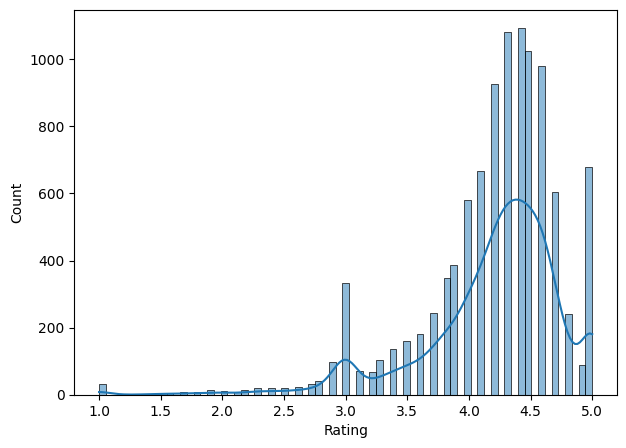

In [189]:
plt.figure(figsize=(7,5))
sns.histplot(data, x= 'Rating', kde=True)
plt.show()

<hr />
2- Which category (Category) has the highest number of applications?



In [190]:
data.Category.value_counts()

Category
FAMILY                 1944
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
Name: count, dtype: int64

<hr />
3-What is the average rating (Rating) in each category?



In [191]:
data.groupby('Category')['Rating'].mean()

Category
ART_AND_DESIGN         4.329231
AUTO_AND_VEHICLES      4.184706
BEAUTY                 4.213208
BOOKS_AND_REFERENCE    4.323478
BUSINESS               4.154801
COMICS                 4.151667
COMMUNICATION          4.143989
DATING                 4.080102
EDUCATION              4.377692
ENTERTAINMENT          4.136036
EVENTS                 4.376563
FAMILY                 4.188837
FINANCE                4.125556
FOOD_AND_DRINK         4.188710
GAME                   4.277698
HEALTH_AND_FITNESS     4.284641
HOUSE_AND_HOME         4.178750
LIBRARIES_AND_DEMO     4.087059
LIFESTYLE              4.120643
MAPS_AND_NAVIGATION    4.019708
MEDICAL                4.163235
NEWS_AND_MAGAZINES     4.140530
PARENTING              4.183333
PERSONALIZATION        4.344072
PHOTOGRAPHY            4.169876
PRODUCTIVITY           4.221867
SHOPPING               4.248214
SOCIAL                 4.273571
SPORTS                 4.219943
TOOLS                  4.067141
TRAVEL_AND_LOCAL       4.086498

<hr />
4- What percentage of applications are free and what percentage are paid?



In [192]:
data.Type.value_counts(normalize=True).mul(100)

Type
0.0    92.614404
1.0     7.385596
Name: proportion, dtype: float64

<hr />
5- What is the difference in average rating between free and paid applications?



In [193]:
data.groupby('Type')['Rating'].mean()

Type
0.0    4.183113
1.0    4.270588
Name: Rating, dtype: float64

<hr />
6- What is the distribution of prices for paid applications?



<Axes: xlabel='Price', ylabel='Count'>

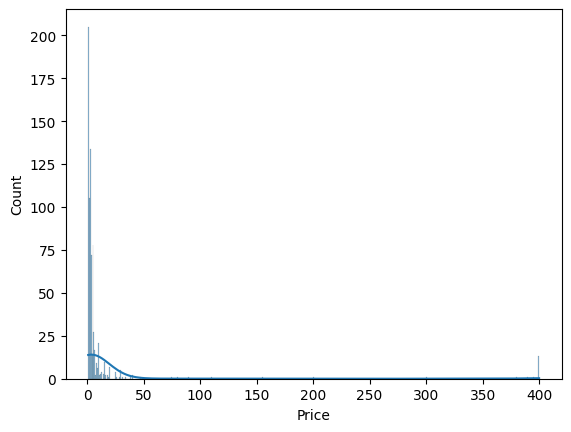

In [194]:
sns.histplot(data=data[data.Type==1],x='Price',kde=True)

<hr />
7- Is there a relationship between the number of installs (Installs) and the rating (Rating)?



In [195]:
corr = data[['Installs','Rating']].corr()
print(corr)

          Installs    Rating
Installs  1.000000  0.041914
Rating    0.041914  1.000000


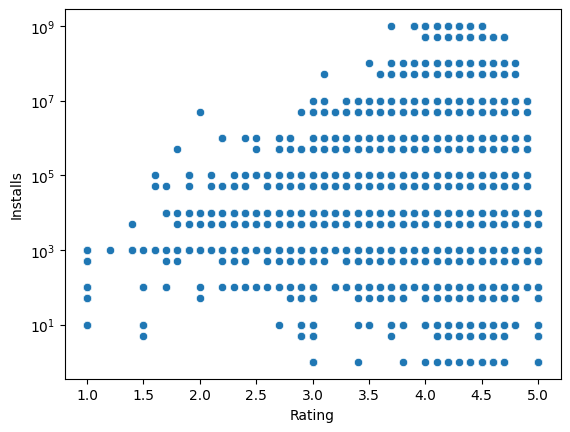

In [196]:
sns.scatterplot(data,x='Rating', y='Installs')
plt.yscale('log')

<hr />
8- What is the relationship between the number of reviews (Reviews) and the number of installs?



In [197]:
corr = data[['Installs','Reviews']].corr()
print(corr)

          Installs   Reviews
Installs  1.000000  0.634952
Reviews   0.634952  1.000000


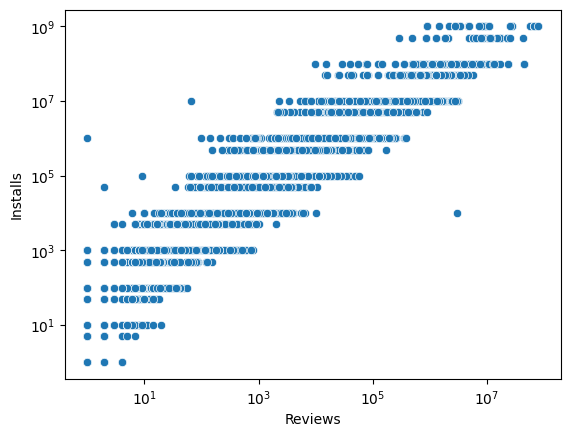

In [198]:
sns.scatterplot(data,x='Reviews', y='Installs')
plt.yscale('log')
plt.xscale('log')

<hr />
9- Which applications have the highest number of installs?



In [199]:
data[['App','Installs']].sort_values(by='Installs', ascending=False).head(10)

,App,Installs
5856,Google Play Games,1.000000e+09
4098,Maps - Navigate & Explore,1.000000e+09
4150,Google,1.000000e+09
3943,Facebook,1.000000e+09
4144,Google+,1.000000e+09
3736,Google News,1.000000e+09
335,Messenger – Text and Video Chat for Free,1.000000e+09
2884,Google Photos,1.000000e+09
338,Google Chrome: Fast & Secure,1.000000e+09
1700,Subway Surfers,1.000000e+09


<hr />
10- Do applications with high ratings usually have more reviews?



<Axes: xlabel='Rating', ylabel='Reviews'>

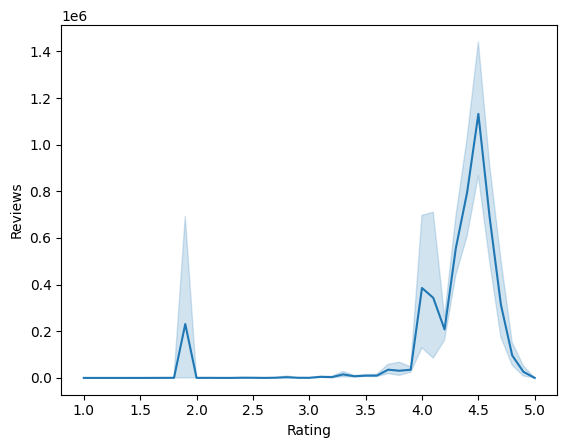

In [200]:
sns.lineplot(data, x='Rating', y='Reviews')

<hr />
11- In which year were most applications updated?



In [201]:
data['Year'] = data.Last_Updated.dt.year
data.Year.value_counts()

Year
2018    6935
2017    1826
2016     789
2015     454
2014     204
2013     108
2012      26
2011      15
2010       1
Name: count, dtype: int64

<hr />
12- Has the average rating changed over time?



In [202]:
data.groupby('Year')['Rating'].mean()

Year
2010    4.200000
2011    3.966667
2012    3.746154
2013    4.037037
2014    4.025980
2015    4.093172
2016    4.073004
2017    4.097426
2018    4.242740
Name: Rating, dtype: float64

<hr />
13- Is there a relationship between the required Android version (Android_Ver) and the rating?



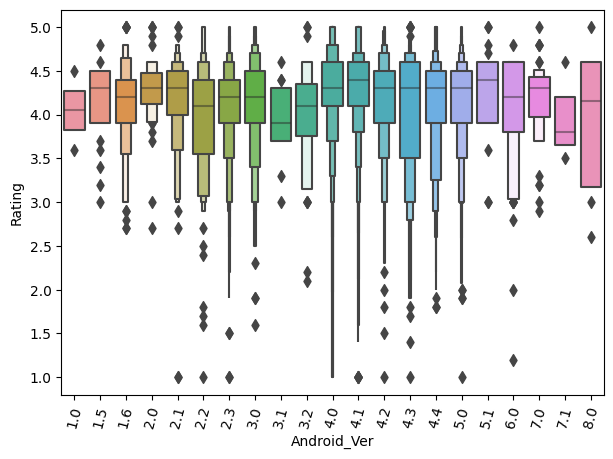

In [203]:
plt.figure(figsize=(7,5))
sns.boxenplot(data, x='Android_Ver', y='Rating')
plt.tick_params(axis='x', rotation=75)

<hr />
14- In what range do most applications' current versions (Current_Ver) fall?



Min: 0.10000000000000009    Max: 9.9


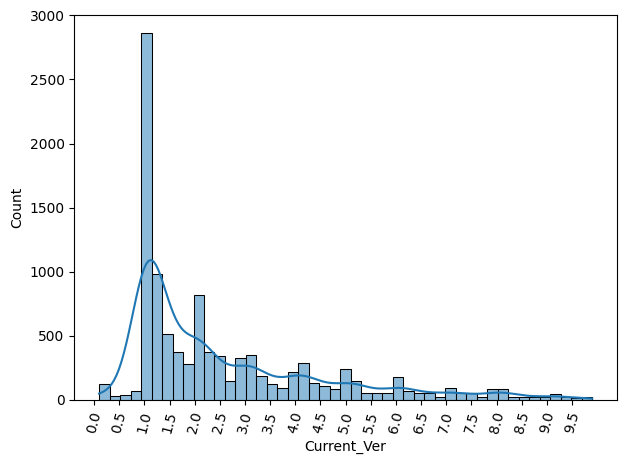

In [204]:
print('Min:',data.Current_Ver.min(),'   Max:',data.Current_Ver.max())
plt.figure(figsize=(7,5))
sns.histplot(data,x='Current_Ver',kde=True)
plt.xticks(np.arange(0,10,0.5))
plt.tick_params(axis='x',rotation=75)


<hr />
15- What factors have the greatest impact on application ratings?



In [205]:
corr = data.corr(numeric_only=True)
corr.Rating.sort_values(ascending=False)

Rating            1.000000
Year              0.118687
Size_num          0.075810
Android_Ver       0.058457
Reviews           0.056486
Installs          0.041914
Current_Ver       0.039896
Type              0.039520
Content_Rating    0.035630
Price            -0.017745
Name: Rating, dtype: float64

<hr />
16- Display the distribution of Rating by Category using a Boxplot and detect Outliers?



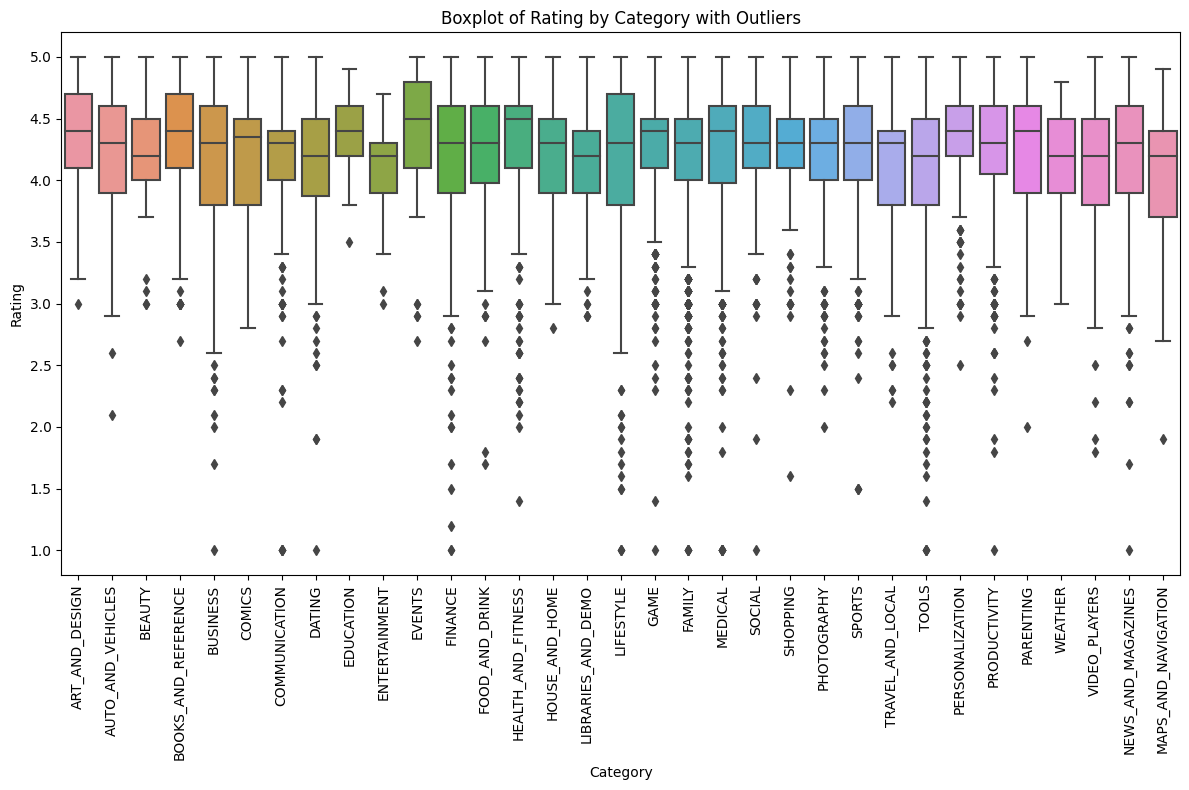

In [206]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=data, x='Category',y='Rating' ,)
plt.xticks(rotation=90)
plt.title('Boxplot of Rating by Category with Outliers')
plt.tight_layout()
plt.show()

<hr />
17 – Display the strong correlation relationships among the numerical features (Rating, Reviews, Installs, Price, Size) using a heatmap.

<Axes: >

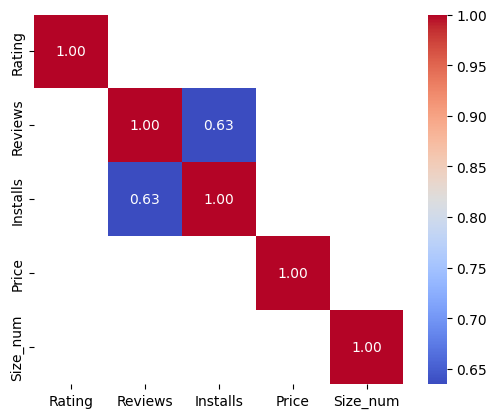

In [207]:
cols =['Rating','Reviews','Installs','Price','Size_num']
corr = data[cols].corr()
corr[(corr < 0.5) & (corr > -0.5)] =np.nan
sns.heatmap(corr, annot_kws={'size':10}, annot=True,square=True,cmap='coolwarm',fmt='.2f', cbar=True)

<hr />
18 – Compare the top 10 categories based on Average Rating and Total Installs using a dual-axis bar plot.

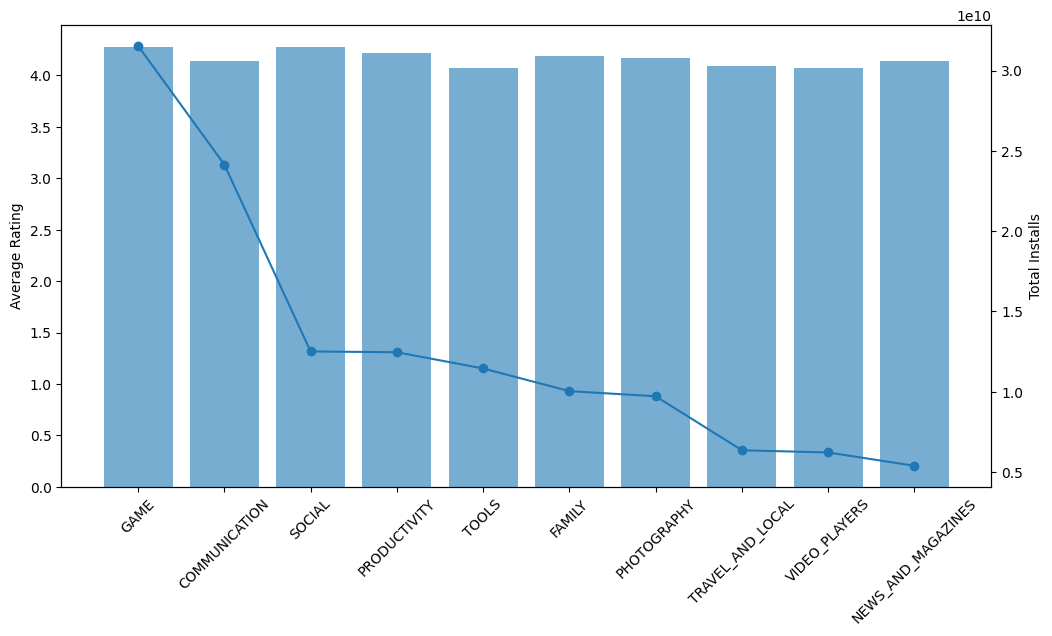

In [208]:
category_stats = data.groupby('Category').agg({'Rating':'mean','Installs':'sum'}).sort_values(by='Installs', ascending=False).head(10)
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(category_stats.index, category_stats['Rating'], label='Average Rating', alpha=0.6)
ax1.set_ylabel('Average Rating')
ax1.set_xticks(range(len(category_stats.index)))
ax1.set_xticklabels(category_stats.index, rotation=45)

ax2 = ax1.twinx()
ax2.plot(category_stats.index, category_stats['Installs'], marker='o', label='Total Installs')
ax2.set_ylabel('Total Installs')
plt.show()

<hr />
19 – Visualize the relationship between Rating and Installs with a regression line, faceted by Type (Free/Paid), using a scatter plot.

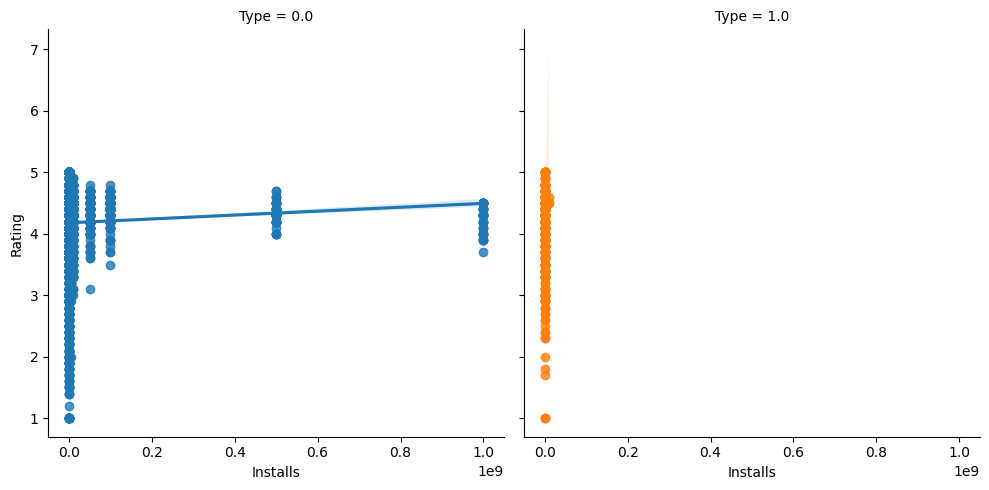

In [209]:
g = sns.FacetGrid(data=data,col='Type',hue='Type',height=5)
g.map_dataframe(sns.regplot,x= 'Installs', y='Rating')


<hr />
20 – Visualize the distribution of Size based on Content Rating using a violin plot.

<Axes: xlabel='Content_Rating', ylabel='Size_num'>

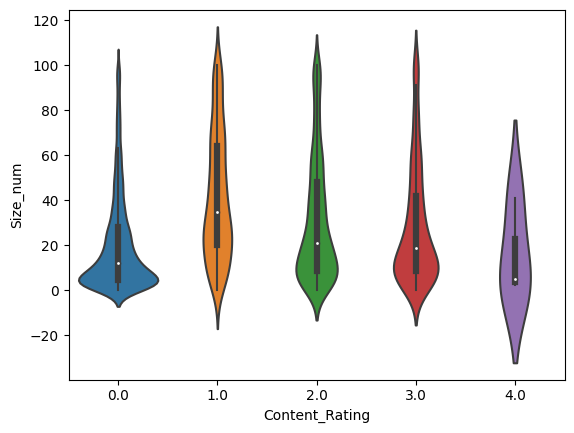

In [210]:
sns.violinplot(data, x='Content_Rating', y='Size_num')

<hr />
21 – Display the pairwise relationships among the numerical features (Rating, Reviews, Installs, Price) using a pairplot with hue=Category (for the Top 5 categories).

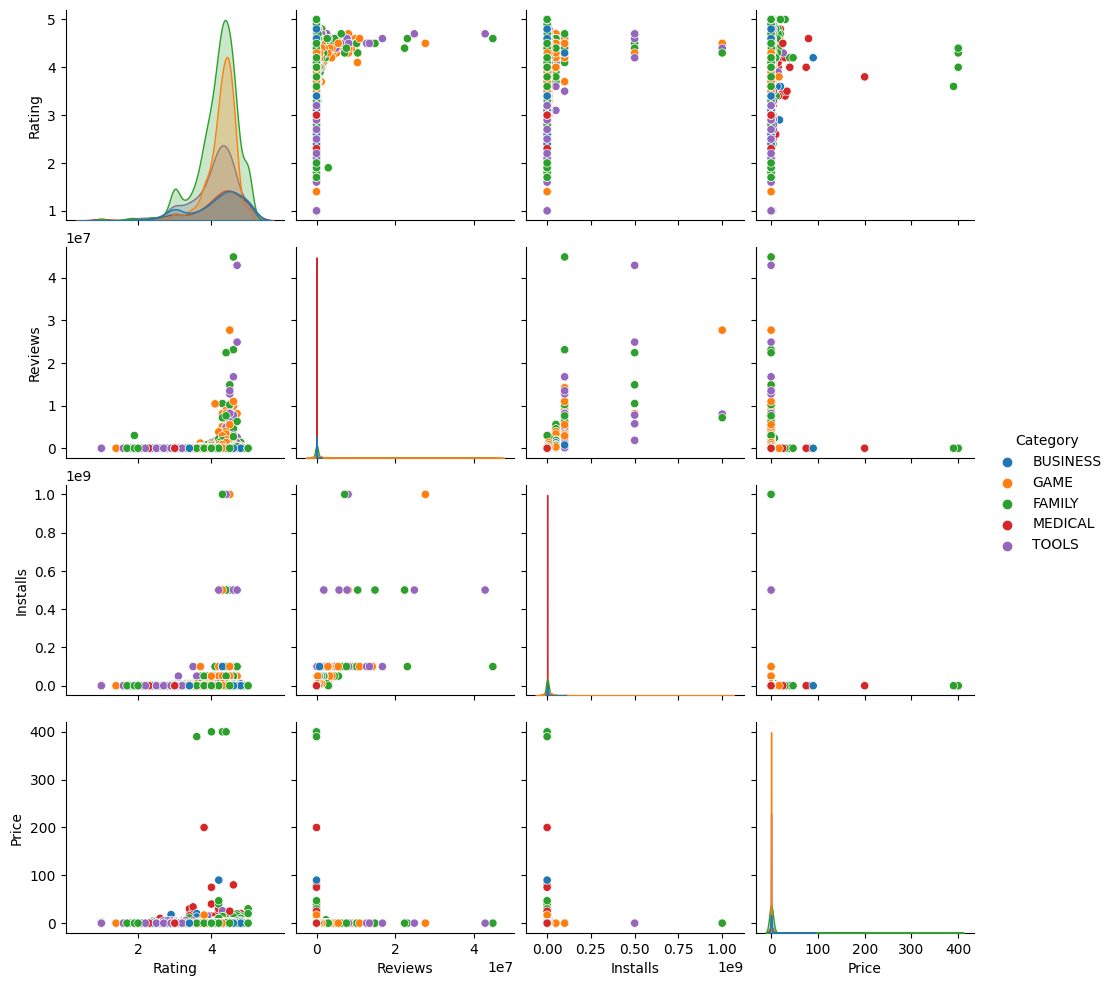

In [211]:
top_5 = data.Category.value_counts().head(5).index
subset = data[data.Category.isin(top_5)]
sns.pairplot(subset, vars=['Rating', 'Reviews', 'Installs', 'Price'], hue='Category',palette='tab10')

<hr />
22 – Visualize the time trend of the Average Rating based on the ‘Last Updated’ date (resampled monthly) using a line plot along with seasonal decomposition.

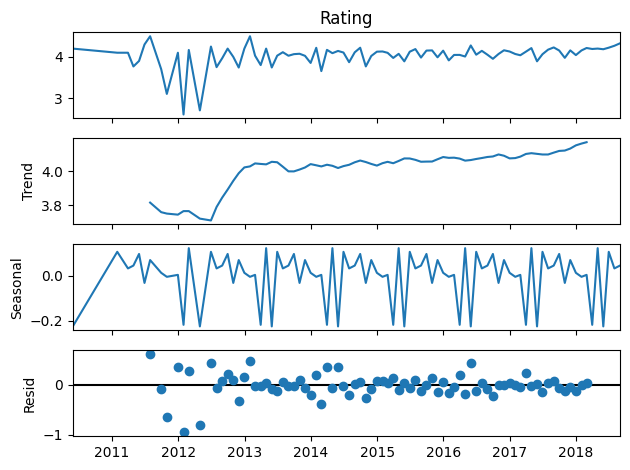

In [212]:
from statsmodels.tsa.seasonal import seasonal_decompose
data_time = data.groupby('Last_Updated')['Rating'].mean().resample('ME').mean().dropna()
#sns.lineplot(x=data_time.index, y=data_time.values)

decomp = seasonal_decompose(data_time, model='additive', period=12)
decomp.plot()
plt.show()

<hr />
23 – Display the average number of Installs by Genre and Type using a pivot table heatmap.

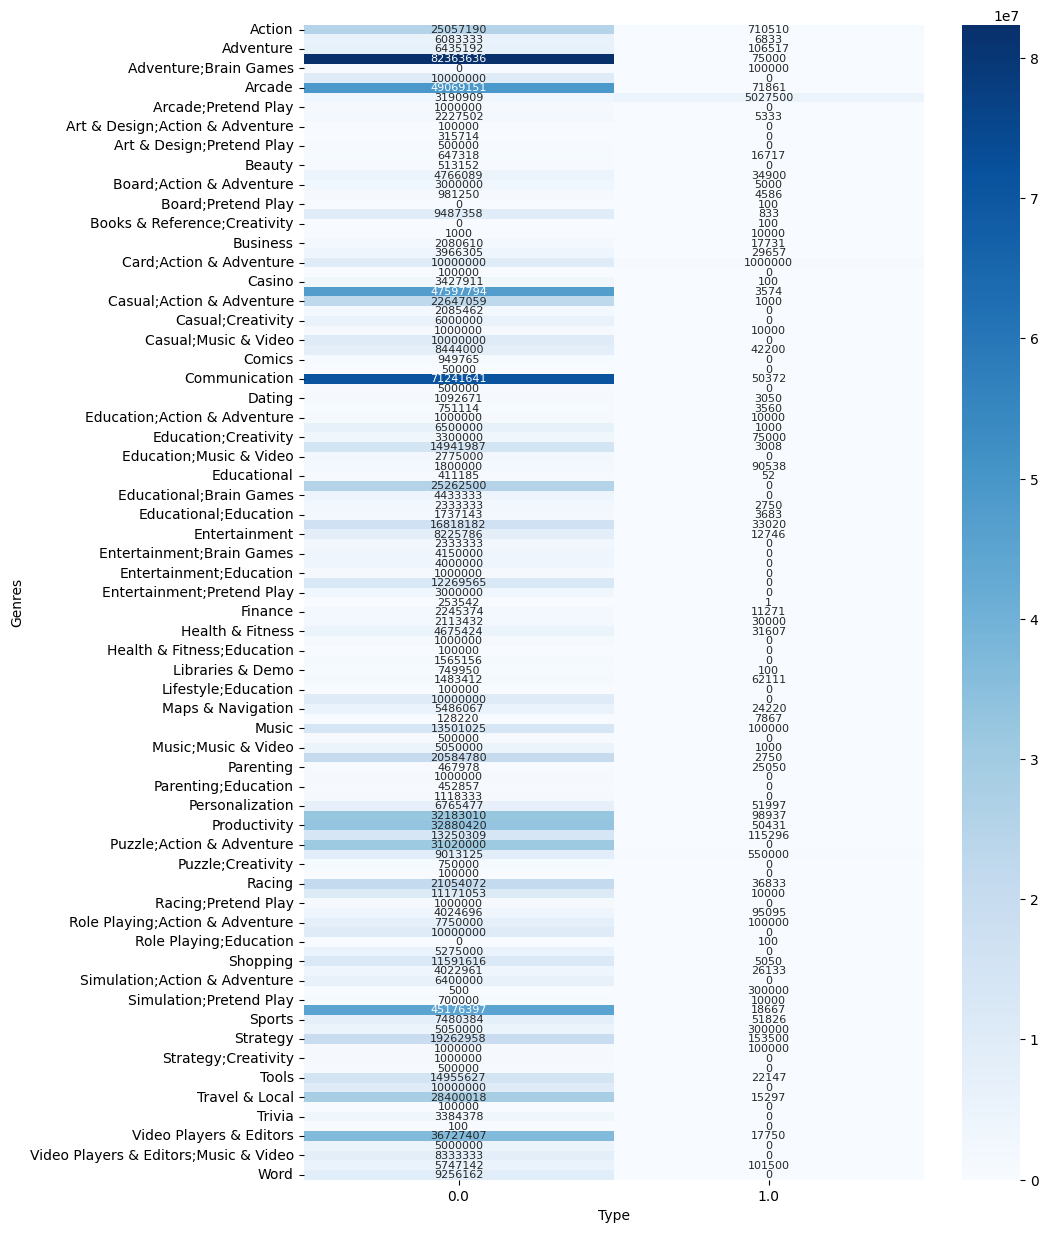

In [213]:
pvot_table = pd.pivot_table(data,
    values='Installs',
    index='Genres',
    columns='Type',
    aggfunc='mean',
    fill_value=0)
plt.figure(figsize=(10, 15))
sns.heatmap(pvot_table, annot=True, cmap='Blues',cbar=True, fmt='.0f',annot_kws={'size':8})
plt.show()

<hr />
24 – Which apps have the highest "Installs-to-Size" ratio?

In [214]:
data['installs_per_mb'] = data.Installs / data.Size_num
data.nlargest(10, 'installs_per_mb')[['App','Category','installs_per_mb']]

,App,Category,installs_per_mb
340,Gmail,COMMUNICATION,4.761905e+08
341,Hangouts,COMMUNICATION,4.761905e+08
386,Hangouts,COMMUNICATION,4.761905e+08
451,Gmail,COMMUNICATION,4.761905e+08
464,Hangouts,COMMUNICATION,4.761905e+08
3127,Google Street View,TRAVEL_AND_LOCAL,4.761905e+08
3232,Google Street View,TRAVEL_AND_LOCAL,4.761905e+08
3234,Google,TOOLS,4.761905e+08
3454,Google Drive,PRODUCTIVITY,4.761905e+08
3523,Google Drive,PRODUCTIVITY,4.761905e+08


<hr />
25 – Do apps that have been updated recently have higher Ratings?

In [215]:
max_date = data.Last_Updated.max()
data['days_since_update'] = (max_date - data.Last_Updated).dt.days
bins = [0, 90, 365, np.inf]
labels = ['Recent (<=90d)', 'Mid (91-365d)', 'Old (>365d)']
data['recency_bin'] = pd.cut(data.days_since_update, bins=bins, labels=labels, include_lowest=True)
grouped = data.groupby('recency_bin',observed=True)['Rating'].agg(['mean', 'median', 'count', 'std'])
print(grouped)

                    mean  median  count       std
recency_bin                                      
Recent (<=90d)  4.258105     4.4   5361  0.496835
Mid (91-365d)   4.156488     4.3   2551  0.661356
Old (>365d)     4.073876     4.2   2446  0.630526


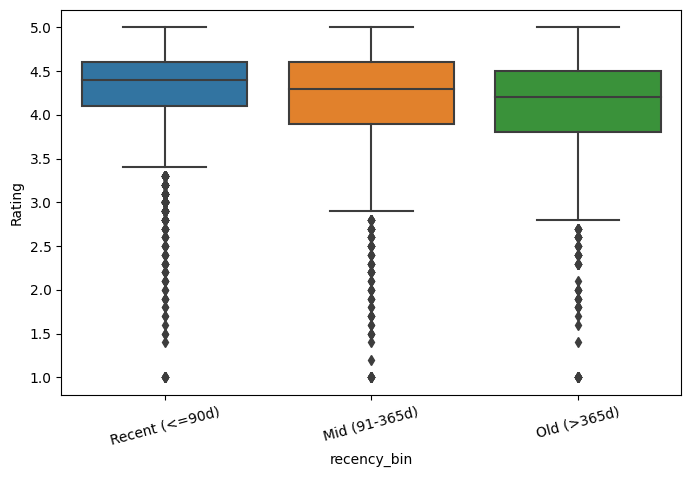

In [216]:
plt.figure(figsize=(8,5))
sns.boxplot(data, x='recency_bin', y='Rating', order=labels)
plt.ylabel('Rating')
plt.xticks(rotation=15)
plt.show()

<hr />
26 – Which app categories have the highest "potential revenue"?

In [217]:
data['revenue'] = data.Price * data.Installs
data.groupby('Category')['revenue'].sum().sort_values(ascending=False).head(10)

Category
FAMILY             1.857819e+08
LIFESTYLE          5.798393e+07
GAME               4.098764e+07
FINANCE            2.773262e+07
PHOTOGRAPHY        8.942768e+06
MEDICAL            8.456736e+06
PERSONALIZATION    7.794398e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313530e+06
Name: revenue, dtype: float64

<hr />
27 – Which are the top 5 apps in terms of Rating within each category?

In [218]:
pd.set_option('display.max_rows', None)
data.sort_values(['Category','Rating'], ascending=[True,False]) \
.groupby('Category').head(5)[['Category','App','Rating','Installs']]


,Category,App,Rating,Installs
8888,ART_AND_DESIGN,Spring flowers theme couleurs d t space,5.0,100.0
25,ART_AND_DESIGN,Harley Quinn wallpapers HD,4.8,10000.0
3982,ART_AND_DESIGN,Cardi B Wallpaper,4.8,50000.0
4759,ART_AND_DESIGN,X Launcher Pro - IOS Style Theme & Control Center,4.8,10000.0
5254,ART_AND_DESIGN,AJ Styles HD Wallpapers,4.8,5000.0
5247,AUTO_AND_VEHICLES,AJ AUTO,5.0,10.0
6151,AUTO_AND_VEHICLES,BG Middle East,5.0,10.0
7790,AUTO_AND_VEHICLES,CR Monitor,5.0,5.0
10764,AUTO_AND_VEHICLES,FP Transportation,5.0,1.0
55,AUTO_AND_VEHICLES,Tickets SDA 2018 and Exam from the State Traff...,4.9,100000.0


<hr />
28 – Which apps have a very high number of installs but low Ratings?

In [219]:
high_low = data[(data.Installs > data.Installs.quantile(0.9)) & (data.Rating < data.Rating.quantile(0.3))]
high_low[['App','Installs','Rating']].head(10)

,App,Installs,Rating
152,Google Play Books,1.000000e+09,3.9
201,Facebook Pages Manager,5.000000e+07,4.0
225,Secure Folder,5.000000e+07,3.8
335,Messenger – Text and Video Chat for Free,1.000000e+09,4.0
341,Hangouts,1.000000e+09,4.0
382,Messenger – Text and Video Chat for Free,1.000000e+09,4.0
386,Hangouts,1.000000e+09,4.0
464,Hangouts,1.000000e+09,4.0
874,Talking Angela,1.000000e+08,3.7
2550,Snapchat,5.000000e+08,4.0


<hr />
29 – Which categories have the most expensive apps?

In [220]:
data[data.Type==1].groupby('Category')['Price'].mean().sort_values(ascending=False)

Category
FINANCE                170.637059
LIFESTYLE              124.256316
EVENTS                 109.990000
BUSINESS                14.607500
FAMILY                  12.945561
MEDICAL                 12.151071
PRODUCTIVITY             8.961786
PHOTOGRAPHY              6.111500
MAPS_AND_NAVIGATION      5.390000
SOCIAL                   5.323333
PARENTING                4.790000
DATING                   4.490000
EDUCATION                4.490000
AUTO_AND_VEHICLES        4.490000
HEALTH_AND_FITNESS       4.290000
BOOKS_AND_REFERENCE      4.277500
FOOD_AND_DRINK           4.240000
SPORTS                   4.166667
TRAVEL_AND_LOCAL         4.162500
WEATHER                  4.052500
ENTERTAINMENT            3.990000
GAME                     3.461446
TOOLS                    3.426282
COMMUNICATION            3.079259
SHOPPING                 2.740000
VIDEO_PLAYERS            2.615000
NEWS_AND_MAGAZINES       1.990000
ART_AND_DESIGN           1.990000
PERSONALIZATION          1.847195
LIBRA

<hr />
30 – Which categories have the most consistent quality?

In [221]:
data.groupby('Category')['Rating'].std().sort_values(ascending=False).head(5)

Category
LIFESTYLE    0.790860
MEDICAL      0.779952
BUSINESS     0.724225
FINANCE      0.667688
TOOLS        0.651091
Name: Rating, dtype: float64

<hr />
31 – Which apps are old but still have a high number of installs?

In [222]:
old_popular = data[(data.days_since_update > data.days_since_update.median())&(data.Installs > data.Installs.median())]
old_popular[['App','days_since_update','Installs']].sort_values(by='days_since_update',ascending=False).head(10)

,App,days_since_update,Installs
8418,DEER HUNTER CHALLENGE,2676,5000000.0
1544,Apk Installer,2597,1000000.0
7080,Bubble,2586,5000000.0
5561,Satellite AR,2512,1000000.0
7487,CONTRACT KILLER: ZOMBIES,2442,5000000.0
1523,Aviary Stickers: Free Pack,2395,10000000.0
7414,CJ: Strike Back,2182,1000000.0
4896,Ladies' Ab Workout FREE,2130,1000000.0
4635,ENCHANT U,2099,500000.0
5060,easyFocus,2079,500000.0
